# Llama last-layer repair: how protected bits fall with more examples

We retain the original model's **full quantized logit vector** on (N) real text inputs. After 64 last-layer weights are changed, the examples rank likely damaged locations. A protected syndrome then restores the values.

The experiment measures the number of protected checks required by the decoder:

\[
t=e+2u,
\]

where (e) locations are flagged from the examples and (u) actual errors remain outside them. Each check costs 31 protected bits. The erasure count and certificate length are selected on development trials, then frozen for test trials.

The primary experiment compares BF16 and row-wise INT8 heads under matched sparse numerical changes. INT4 is retained only as a secondary pre-tamper utility control. Quantized heads store one BF16 scale per output row, and that storage is counted. All heads use FP32 last-layer accumulation with TF32 disabled and 8-bit retained logits. FP32 is working arithmetic, not extra information available to the decoder. Ordinary output storage (N\times V\times8) and protected storage (31t) are reported separately.


In [1]:
# Run once if needed.
# %pip install -q "torch>=2.4" "transformers>=4.48" "datasets>=3.2" scipy pandas matplotlib tqdm


In [2]:
from dataclasses import dataclass, asdict
from pathlib import Path
import gc, json, math, os, random, time

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from datasets import load_dataset
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer

@dataclass(frozen=True)
class Config:
    model_id: str = "meta-llama/Meta-Llama-3.1-8B-Instruct"
    hf_cache_dir: str = "/scratch/bbjr/skarmakar/huggingface"
    model_revision: str | None = None       # pin before final experiments
    dataset_revision: str | None = None
    seed: int = 17
    out_dir: str = "repair_runs/matched_precision"
    cache_dir: str = "repair_runs/certificate_pilot"  # reuse the completed run's caches
    n_grid: tuple = (64, 128, 256)
    sparsity: int = 64
    output_bits: int = 8
    model_bits: tuple = (16, 8, 4)          # build INT4 only for the secondary utility control
    experiment_bits: tuple = (16, 8)        # matched primary comparison
    scale_bits: int = 16                    # one intact BF16 scale per output row
    accumulation_bits: int = 32            # declared last-layer arithmetic
    fixed_logit_range: float = 64.0
    rho_multiple: float = 10.0              # public maximum |weight change|
    tamper_fraction_of_bound: float = 0.9
    constraint_slack: float = 1e-4          # declared FP32 numerical tolerance
    erasure_grid: tuple = (0, 16, 32, 48, 64)
    dev_trials: int = 10
    test_trials: int = 30
    cal_contexts: int = 96
    dev_pool: int = 384
    test_pool: int = 384
    behavior_contexts: int = 128
    context_tokens: int = 256
    feature_batch: int = 24
    head_batch: int = 32
    solver_steps: int = 350                 # fixed trial budget; diagnostic also checks 1400
    solver_check_every: int = 50
    solver_tol: float = 1e-4

CFG=Config()
assert torch.cuda.is_available(), "A CUDA GPU is required."
assert CFG.output_bits==8, "This pilot uses uint8 output codes."
assert CFG.model_bits==(16,8,4) and CFG.experiment_bits==(16,8)
assert CFG.accumulation_bits==32
assert max(CFG.n_grid)<=min(CFG.dev_pool,CFG.test_pool)
DEVICE=torch.device("cuda")
torch.manual_seed(CFG.seed); np.random.seed(CFG.seed); random.seed(CFG.seed)
torch.set_grad_enabled(False)
torch.backends.cuda.matmul.allow_tf32=False
torch.set_float32_matmul_precision("highest")
OUT=Path(CFG.out_dir); OUT.mkdir(parents=True,exist_ok=True)
CACHE=Path(CFG.cache_dir); CACHE.mkdir(parents=True,exist_ok=True)
print(torch.cuda.get_device_name())
print(asdict(CFG))


NVIDIA H200
{'model_id': 'meta-llama/Meta-Llama-3.1-8B-Instruct', 'hf_cache_dir': '/scratch/bbjr/skarmakar/huggingface', 'model_revision': None, 'dataset_revision': None, 'seed': 17, 'out_dir': 'repair_runs/matched_precision', 'cache_dir': 'repair_runs/certificate_pilot', 'n_grid': (64, 128, 256), 'sparsity': 64, 'output_bits': 8, 'model_bits': (16, 8, 4), 'experiment_bits': (16, 8), 'scale_bits': 16, 'accumulation_bits': 32, 'fixed_logit_range': 64.0, 'rho_multiple': 10.0, 'tamper_fraction_of_bound': 0.9, 'constraint_slack': 0.0001, 'erasure_grid': (0, 16, 32, 48, 64), 'dev_trials': 10, 'test_trials': 30, 'cal_contexts': 96, 'dev_pool': 384, 'test_pool': 384, 'behavior_contexts': 128, 'context_tokens': 256, 'feature_batch': 24, 'head_batch': 32, 'solver_steps': 350, 'solver_check_every': 50, 'solver_tol': 0.0001}


## Diagnostic helper definitions

These helpers are used by the diagnostic cell after Section 3.


In [3]:
def diagnostic_problem(h,codes,current_codes,tamper,n=256):
    h=h[:n].to(DEVICE,dtype=torch.float32)
    mismatch=(codes[:n]!=current_codes[:n]).any(0)
    bad_rows=torch.nonzero(mismatch,as_tuple=False).flatten().cpu().numpy()
    if not len(bad_rows): return None
    rows=torch.as_tensor(bad_rows,device=DEVICE)
    current=W32[rows].clone()  # W32 is the currently installed checkpoint
    correction=torch.zeros_like(current)
    row_pos={int(r):i for i,r in enumerate(bad_rows)}
    for r,c,old,new in zip(tamper["rows"],tamper["cols"],tamper["old"],tamper["new"]):
        if int(r) in row_pos:
            i=row_pos[int(r)]
            correction[i,int(c)]=old.float()-new.float()
    cur=current@h.T
    q=codes[:n,torch.as_tensor(bad_rows)].T.to(DEVICE,dtype=torch.float32)
    lower=(-R+q*WIDTH)-cur-CFG.constraint_slack
    upper=(-R+(q+1)*WIDTH)-cur+CFG.constraint_slack
    return h,bad_rows,lower,upper,correction

def max_violation(values,lower,upper):
    return float(torch.maximum((lower-values).clamp_min(0).max(),
                               (values-upper).clamp_min(0).max()))


## 1. One real input distribution

We use nonempty text rows from the raw WikiText-2 splits. A context is sampled with replacement from a fixed split-specific pool, so each trial is iid from that empirical distribution. Development and test pools are separate. Each text produces one hidden state at its final retained token.

Inputs and their order are assumed available ordinary data. The stored output is the original model's full vocabulary logit vector quantized by a public uniform 8-bit quantizer over ([-64,64]). No generated tokens or labels are used.


In [4]:
ds=load_dataset("Salesforce/wikitext","wikitext-2-raw-v1",revision=CFG.dataset_revision)

def choose_texts(split,n,seed):
    texts=[x["text"].strip() for x in ds[split] if len(x["text"].strip())>=80]
    if len(texts)<n: raise RuntimeError(f"Only {len(texts)} usable {split} rows; need {n}")
    rng=np.random.default_rng(seed)
    return [texts[i] for i in rng.choice(len(texts),n,replace=False)]

texts={
    "cal":choose_texts("train",CFG.cal_contexts,CFG.seed),
    "dev":choose_texts("validation",CFG.dev_pool,CFG.seed+1),
    "test":choose_texts("test",CFG.test_pool+CFG.behavior_contexts,CFG.seed+2),
}
texts["behavior"]=texts["test"][-CFG.behavior_contexts:]
texts["test"]=texts["test"][:-CFG.behavior_contexts]
print({k:len(v) for k,v in texts.items()})


{'cal': 96, 'dev': 384, 'test': 384, 'behavior': 128}


In [5]:
tokenizer=AutoTokenizer.from_pretrained(CFG.model_id, cache_dir=CFG.hf_cache_dir, revision=CFG.model_revision)
tokenizer.padding_side="left"
if tokenizer.pad_token_id is None: tokenizer.pad_token=tokenizer.eos_token
model=AutoModelForCausalLM.from_pretrained(
    CFG.model_id, cache_dir=CFG.hf_cache_dir, revision=CFG.model_revision, torch_dtype=torch.bfloat16,
    low_cpu_mem_usage=True, attn_implementation="sdpa"
).eval().to(DEVICE)
assert hasattr(model,"lm_head") and not bool(getattr(model.config,"tie_word_embeddings",True))
V,D=model.lm_head.weight.shape
W=model.lm_head.weight.detach()                 # BF16, kept on GPU

def hidden_states(items,name):
    path=CACHE/f"hidden_{name}.pt"
    if path.exists(): return torch.load(path,map_location="cpu",weights_only=True)
    out=[]
    for start in tqdm(range(0,len(items),CFG.feature_batch),desc=f"features:{name}"):
        enc=tokenizer(items[start:start+CFG.feature_batch],return_tensors="pt",padding=True,
                      truncation=True,max_length=CFG.context_tokens).to(DEVICE)
        with torch.inference_mode(),torch.autocast("cuda",dtype=torch.bfloat16):
            h=model.model(**enc,use_cache=False,return_dict=True).last_hidden_state
        # With left padding, the final non-padding token is the final tensor position.
        out.append(h[:,-1].float().cpu())
    h=torch.cat(out); torch.save(h,path); return h

H={k:hidden_states(v,k) for k,v in texts.items()}
assert W.dtype==torch.bfloat16
assert all(torch.equal(h,h.to(torch.bfloat16).float()) for h in H.values()), \
       "Hidden-state cache is not exactly BF16; remove it and recompute."
weight_rms=float(W.float().square().mean().sqrt())
rho=CFG.rho_multiple*weight_rms
tamper_step=CFG.tamper_fraction_of_bound*rho
del model; gc.collect(); torch.cuda.empty_cache()
W16=W.float()  # exact FP32 representation of the stored BF16 values
HEADS={16:W16}; QUANT_LABELS={}; QUANT_SCALES={}
row_max=W16.abs().amax(1)
for bits in (8,4):
    qmax=2**(bits-1)-1
    scale=(row_max/qmax).to(torch.bfloat16).float()
    if bool((scale<=0).any()): raise RuntimeError("Zero row scale in quantized head.")
    signed=torch.round(W16/scale[:,None]).clamp(-qmax,qmax).to(torch.int16)
    QUANT_LABELS[bits]=(signed+qmax).to(torch.uint8)
    QUANT_SCALES[bits]=scale
    HEADS[bits]=signed.float()*scale[:,None]
W32=W16
print({"vocab":V,"hidden":D,"head_entries":V*D,"weight_rms":weight_rms,
       "rho_bound":rho,"tamper_step":tamper_step,
       "precision":"BF16 body; BF16/INT8/INT4 heads; FP32 accumulation; 8-bit outputs"})


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

{'vocab': 128256, 'hidden': 4096, 'head_entries': 525336576, 'weight_rms': 0.01426707860082388, 'rho_bound': 0.1426707860082388, 'tamper_step': 0.1284037074074149, 'precision': 'BF16 body; BF16/INT8/INT4 heads; FP32 accumulation; 8-bit outputs'}


## 2. Store the original predictions and define tampers

INT8 and INT4 use symmetric row-wise quantization with one BF16 scale per output row. Scales are part of the checkpoint, their storage is counted, and the allowed tamper changes only weight codes—not scales. For each trial we first generate a legal INT8 code change, then apply that exact numerical change to the BF16 head and round once to BF16. The remaining mismatch is reported. INT4 is not rerun in the matched trial grid because its completed run already serves as the secondary control.

- **dispersed:** one changed weight in each of 64 output rows;
- **concentrated:** 64 changed weights in one output row.

Rows and columns are sampled from calibration-important pools. Test examples and test outputs do not choose the tamper.


In [6]:
R=float(CFG.fixed_logit_range); WIDTH=2*R/(2**CFG.output_bits)

def qcode(z):
    if bool(((z < -R)|(z >= R)).any()):
        raise RuntimeError("Public logit range saturated; enlarge it and restart the experiment.")
    return torch.floor((z+R)/WIDTH).to(torch.uint8)

def original_codes(h,name,weight_bits,head):
    # Precision and range tags prevent reuse under a different numerical contract.
    quant_tag=f"row_scale{CFG.scale_bits}" if weight_bits<16 else "native"
    path=CACHE/f"codes_{name}_w{weight_bits}_{quant_tag}_acc{CFG.accumulation_bits}_y{CFG.output_bits}_v4.pt"
    if path.exists(): return torch.load(path,map_location="cpu",weights_only=True)
    chunks=[]
    for start in tqdm(range(0,len(h),CFG.head_batch),desc=f"stored outputs:{name}"):
        hb=h[start:start+CFG.head_batch].to(DEVICE,dtype=torch.float32)
        chunks.append(qcode(hb@head.T).cpu())
    x=torch.cat(chunks); torch.save(x,path); return x

CODES={(b,k):original_codes(H[k],k,b,HEADS[b])
       for b in CFG.experiment_bits for k in ("dev","test")}

# Public calibration rule for relevant rows and coordinates.
with torch.inference_mode():
    hcal=H["cal"].to(DEVICE,dtype=torch.float32)
    logits=hcal@W32.T
    mean_p=torch.softmax(logits,dim=-1).mean(0)
    row_pool=torch.topk(mean_p,min(256,V)).indices.cpu().numpy()
    feature_score=H["cal"].square().mean(0)
    col_pool=torch.topk(feature_score,min(512,D)).indices.cpu().numpy()
    behavior_logits={}
    for bits,head in HEADS.items():
        chunks=[]
        for start in range(0,len(H["behavior"]),CFG.head_batch):
            hb=H["behavior"][start:start+CFG.head_batch].to(DEVICE,dtype=torch.float32)
            chunks.append((hb@head.T).cpu())
        behavior_logits[bits]=torch.cat(chunks)
    behavior_logp={b:torch.log_softmax(z,dim=-1) for b,z in behavior_logits.items()}
    behavior_probs={b:lp.exp() for b,lp in behavior_logp.items()}
    quantization_KL={b:float((behavior_probs[16]*(behavior_logp[16]-behavior_logp[b])).sum(1).mean())
                     for b in CFG.model_bits}
    quantization_TV={b:float((behavior_probs[16]-behavior_probs[b]).abs().sum(1).mean()/2)
                     for b in CFG.model_bits}
print(pd.DataFrame({"weight_bits":CFG.model_bits,
                    "BF16_reference_KL":[quantization_KL[b] for b in CFG.model_bits],
                    "BF16_reference_TV":[quantization_TV[b] for b in CFG.model_bits]}))
del logits,behavior_logits,behavior_logp; torch.cuda.empty_cache()

def bf16_labels(x):
    return (x.detach().cpu().to(torch.bfloat16).view(torch.int16).to(torch.int32).numpy() & 0xffff)

def legal_quantized_change(rr,cc,sign_t,bits):
    qmax=2**(bits-1)-1
    old_label=QUANT_LABELS[bits][rr,cc].to(torch.int64)
    old_signed=old_label-qmax; scale=QUANT_SCALES[bits][rr]
    step=torch.round(torch.full_like(scale,tamper_step)/scale).clamp_min(1).to(torch.int64)
    step=torch.minimum(step,torch.floor(torch.full_like(scale,rho)/scale).to(torch.int64))
    proposed=(old_signed+sign_t.to(torch.int64)*step).clamp(-qmax,qmax)
    unchanged=proposed==old_signed
    proposed=torch.where(unchanged,(old_signed-sign_t.to(torch.int64)*step).clamp(-qmax,qmax),proposed)
    if bool((proposed==old_signed).any()):
        raise RuntimeError(f"INT{bits} row cannot realize a nonzero bounded tamper.")
    new_label=proposed+qmax
    old=old_signed.float()*scale; new=proposed.float()*scale
    return old,new,old_label,new_label

def make_tamper(layout,trial,weight_bits):
    rng=np.random.default_rng(CFG.seed+10000*trial+(0 if layout=="dispersed" else 1))
    if layout=="dispersed":
        rows=rng.choice(row_pool,CFG.sparsity,replace=False)
        cols=rng.choice(col_pool,CFG.sparsity,replace=True)
    else:
        rows=np.repeat(rng.choice(row_pool),CFG.sparsity)
        cols=rng.choice(col_pool,CFG.sparsity,replace=False)
    signs=rng.choice([-1.,1.],CFG.sparsity)
    rr=torch.as_tensor(rows,device=DEVICE); cc=torch.as_tensor(cols,device=DEVICE)
    sign_t=torch.as_tensor(signs,device=DEVICE,dtype=torch.float32)
    old8,new8,old8_label,new8_label=legal_quantized_change(rr,cc,sign_t,8)
    reference_delta=new8-old8
    if weight_bits==16:
        old_bf=W[rr,cc].clone()
        new_bf=(old_bf.float()+reference_delta).to(torch.bfloat16)
        old,new=old_bf.float(),new_bf.float()
        old_label,new_label=bf16_labels(old_bf),bf16_labels(new_bf)
    elif weight_bits==8:
        old,new=old8,new8
        old_label=old8_label.cpu().numpy(); new_label=new8_label.cpu().numpy()
    elif weight_bits==4:
        old,new,old4_label,new4_label=legal_quantized_change(rr,cc,sign_t,4)
        old_label=old4_label.cpu().numpy(); new_label=new4_label.cpu().numpy()
    else: raise ValueError("Unsupported weight precision")
    if bool((new==old).any()): raise RuntimeError("Quantization removed a declared tamper.")
    numeric=(new-old).cpu().numpy()
    reference=reference_delta.cpu().numpy() if weight_bits in (16,8) else np.full_like(numeric,np.nan)
    match_error=np.abs(numeric-reference)
    if np.max(np.abs(numeric))>rho:
        raise RuntimeError("Rounded tamper exceeds the public rho bound.")
    return {"weight_bits":weight_bits,"rows":rows.astype(np.int64),"cols":cols.astype(np.int64),
            "old":old,"new":new,"numeric":numeric,"reference_delta":reference,
            "mean_match_error":float(np.nanmean(match_error)) if weight_bits in (16,8) else np.nan,
            "max_match_error":float(np.nanmax(match_error)) if weight_bits in (16,8) else np.nan,
            "old_label":old_label,"new_label":new_label,
            "index":rows.astype(np.int64)*D+cols.astype(np.int64)}

def damage_metrics(tamper):
    rows=np.unique(tamper["rows"]); pos={v:i for i,v in enumerate(rows)}
    delta=np.zeros((len(H["behavior"]),len(rows)),np.float64)
    hb=H["behavior"].double().numpy()
    for r,c,v in zip(tamper["rows"],tamper["cols"],tamper["numeric"]):
        delta[:,pos[r]]+=hb[:,c]*v
    p=behavior_probs[tamper["weight_bits"]][:,torch.as_tensor(rows)].double().numpy()
    em1=np.expm1(np.clip(delta,-40,40)); Z=1+np.sum(p*em1,axis=1)
    kl=np.log(Z)-np.sum(p*delta,axis=1)
    tv=.5*(np.sum(p*np.abs(np.exp(np.clip(delta,-40,40))/Z[:,None]-1),axis=1)
           +(1-p.sum(1))*np.abs(1/Z-1))
    return float(kl.mean()),float(tv.mean())


   weight_bits  BF16_reference_KL  BF16_reference_TV
0           16           0.000000           0.000000
1            8           0.000182           0.007303
2            4           0.072091           0.140776


## 3. Let the examples rank damaged locations

For each row whose current stored predictions disagree with the retained codes, solve a bounded convex problem: find a small ℓ1 correction that returns its logits to the original quantization cells. The correction is only a score for selecting erasure locations; its proposed values are not trusted.

The full current output is evaluated once at the largest (N), and smaller (N) use nested prefixes. Although only changed rows can disagree in this controlled last-layer experiment, the screen below compares all vocabulary rows and does not receive the true support.


In [7]:
def interval_proposal(Hx,lower,upper,rho,steps):
    # Batched Chambolle-Pock iterations; rows share Hx.
    if len(lower)==0: return torch.empty((0,Hx.shape[1]),device=Hx.device),0.0,0
    gram=Hx@Hx.T if Hx.shape[0]<=Hx.shape[1] else Hx.T@Hx
    norm=torch.linalg.eigvalsh(gram)[-1].clamp_min(1e-30).sqrt()
    step=.99/norm
    E=torch.zeros((len(lower),Hx.shape[1]),device=Hx.device,dtype=torch.float32)
    extra=E.clone(); dual=torch.zeros_like(lower)
    previous_top=None; stable_checks=0; violation=float("inf")
    for iteration in range(1,steps+1):
        u=dual+step*(extra@Hx.T)
        dual=u-step*torch.maximum(lower,torch.minimum(upper,u/step))
        z=E-step*(dual@Hx)
        new=(z.sign()*(z.abs()-step).clamp_min(0)).clamp(-rho,rho)
        extra=2*new-E; E=new
        if iteration%CFG.solver_check_every==0 or iteration==steps:
            values=E@Hx.T
            violation=torch.maximum((lower-values).clamp_min(0).max(),
                                    (values-upper).clamp_min(0).max()).item()
            keep=min(CFG.sparsity,E.numel())
            top=torch.sort(torch.topk(E.abs().flatten(),keep).indices).values
            stable_checks=stable_checks+1 if previous_top is not None and torch.equal(top,previous_top) else 0
            previous_top=top
            if iteration>=300 and violation<=CFG.solver_tol and stable_checks>=3: break
    return E,violation,iteration

def install_tamper(tamper):
    rr=torch.as_tensor(tamper["rows"],device=DEVICE)
    cc=torch.as_tensor(tamper["cols"],device=DEVICE)
    saved=W32[rr,cc].clone()
    W32[rr,cc]=tamper["new"].float()
    return rr,cc,saved

def restore_head(state):
    rr,cc,saved=state; W32[rr,cc]=saved

def current_codes_for_sequence(h):
    out=[]
    for start in range(0,len(h),CFG.head_batch):
        hb=h[start:start+CFG.head_batch].to(DEVICE,dtype=torch.float32)
        out.append(qcode(hb@W32.T).cpu())
    return torch.cat(out)

def location_scores(h,codes,current_codes,n):
    if n==0: return np.empty(0,np.int64),np.empty(0),0,0.0
    h=h[:n].to(DEVICE,dtype=torch.float32)
    mismatch=(codes[:n]!=current_codes[:n]).any(0)
    bad_rows=torch.nonzero(mismatch,as_tuple=False).flatten().cpu().numpy()
    if not len(bad_rows): return np.empty(0,np.int64),np.empty(0),0,0.0
    rows=torch.as_tensor(bad_rows,device=DEVICE)
    current=W32[rows].clone()
    cur=current@h.T
    q=codes[:n,torch.as_tensor(bad_rows)].T.to(DEVICE,dtype=torch.float32)
    lower=(-R+q*WIDTH)-cur-CFG.constraint_slack
    upper=(-R+(q+1)*WIDTH)-cur+CFG.constraint_slack
    proposal,violation,_=interval_proposal(h,lower,upper,rho,CFG.solver_steps)
    flat=proposal.abs().flatten()
    keep=min(CFG.sparsity,len(flat))
    value,where=torch.topk(flat,keep)
    local_row=(where//D).cpu().numpy(); col=(where%D).cpu().numpy()
    index=bad_rows[local_row].astype(np.int64)*D+col.astype(np.int64)
    return index,value.cpu().numpy(),len(bad_rows),violation


## 3a. Smallest useful diagnostic

Run this before Section 4. `true_violation` tests whether each matched correction is feasible under our numerical model. `top64_recall` measures localization before certificate-budget selection.


In [8]:
for layout in ("concentrated","dispersed"):
    paired16=make_tamper(layout,0,16); paired8=make_tamper(layout,0,8)
    assert np.array_equal(paired16["index"],paired8["index"])
    assert np.allclose(paired16["reference_delta"],paired8["numeric"],rtol=0,atol=0)
diagnostics=[]
for weight_bits,layout in [(b,l) for b in CFG.experiment_bits
                           for l in ("concentrated","dispersed")]:
    W32=HEADS[weight_bits]
    tamper=make_tamper(layout,0,weight_bits)
    rng=np.random.default_rng(CFG.seed)
    order=rng.choice(len(H["dev"]),256,replace=True)
    hseq=H["dev"][order]; codes=CODES[(weight_bits,"dev")][torch.as_tensor(order)]
    state=install_tamper(tamper)
    try:
        current_codes=current_codes_for_sequence(hseq)
        problem=diagnostic_problem(hseq,codes,current_codes,tamper)
    finally:
        restore_head(state)
    if problem is None:
        diagnostics.append({"weight_bits":weight_bits,"layout":layout,"bad_rows":0,
                            "true_violation":0.0,
                            "iteration_cap":0,"iterations":0,"solver_violation":0.0,
                            "top64_recall":0.0})
        continue
    h,bad_rows,lower,upper,true_correction=problem
    true_violation=max_violation(true_correction@h.T,lower,upper)
    for steps in (CFG.solver_steps,):
        proposal,solver_violation,iterations=interval_proposal(h,lower,upper,rho,steps)
        flat=proposal.abs().flatten(); keep=min(CFG.sparsity,len(flat))
        where=torch.topk(flat,keep).indices
        candidate=(bad_rows[(where//D).cpu().numpy()].astype(np.int64)*D
                   +(where%D).cpu().numpy().astype(np.int64))
        recall=len(set(candidate.tolist()) & set(tamper["index"].tolist()))/CFG.sparsity
        diagnostics.append({"weight_bits":weight_bits,"layout":layout,"bad_rows":len(bad_rows),
                            "true_violation":true_violation,"iteration_cap":steps,
                            "iterations":iterations,
                            "solver_violation":solver_violation,"top64_recall":recall})
diagnostics=pd.DataFrame(diagnostics)
display(diagnostics)
if diagnostics.true_violation.max()>1e-5:
    raise RuntimeError("Numerical contract failed: do not run Section 4.")
print("Numerical contract passed; the true correction is feasible.")


,weight_bits,layout,bad_rows,true_violation,iteration_cap,iterations,solver_violation,top64_recall
0,16,concentrated,1,0.0,350,350,0.347481,0.218750
1,16,dispersed,64,0.0,350,350,0.204256,0.375000
2,8,concentrated,1,0.0,350,350,0.349886,0.234375
3,8,dispersed,64,0.0,350,350,0.218882,0.390625


Numerical contract passed; the true correction is feasible.


## 3b. Independent concentrated-case solver check

This one-time diagnostic solves the BF16 concentrated instance as a linear program using SciPy/HiGHS, independently of the GPU proposal code. It is not used to select any reported test setting. If its recall is also low, the concentrated limitation is not merely caused by stopping the fast solver early.


In [9]:
from scipy.optimize import linprog
from scipy.sparse import csr_matrix, hstack, vstack

W32=W16; tamper=make_tamper("concentrated",0,16)
rng=np.random.default_rng(CFG.seed)
order=rng.choice(len(H["dev"]),256,replace=True)
hseq=H["dev"][order]; codes=CODES[(16,"dev")][torch.as_tensor(order)]
state=install_tamper(tamper)
try:
    current_codes=current_codes_for_sequence(hseq)
    problem=diagnostic_problem(hseq,codes,current_codes,tamper)
finally:
    restore_head(state)
if problem is None: raise RuntimeError("Concentrated tamper was invisible at N=256.")
h,bad_rows,lower,upper,true_correction=problem
assert len(bad_rows)==1
Hs=csr_matrix(h.cpu().double().numpy())
A=vstack([hstack([Hs,-Hs]),hstack([-Hs,Hs])],format="csr")
b=np.r_[upper[0].cpu().double().numpy(),-lower[0].cpu().double().numpy()]
start=time.time()
lp=linprog(np.ones(2*D),A_ub=A,b_ub=b,bounds=(0,rho),method="highs-ipm",
           options={"primal_feasibility_tolerance":1e-9,
                    "dual_feasibility_tolerance":1e-9,
                    "ipm_optimality_tolerance":1e-9,"time_limit":300})
if not lp.success: raise RuntimeError(f"Independent LP failed: {lp.message}")
e=lp.x[:D]-lp.x[D:]
lp_violation=max(np.maximum(lower[0].cpu().numpy()-e@h.cpu().numpy().T,0).max(),
                 np.maximum(e@h.cpu().numpy().T-upper[0].cpu().numpy(),0).max())
candidate=bad_rows[0]*D+np.argpartition(np.abs(e),-CFG.sparsity)[-CFG.sparsity:]
lp_recall=len(set(candidate.tolist()) & set(tamper["index"].tolist()))/CFG.sparsity
display(pd.DataFrame([{"weight_bits":16,"layout":"concentrated",
                       "solver":"SciPy HiGHS LP","seconds":time.time()-start,
                       "solver_violation":lp_violation,"top64_recall":lp_recall}]))


,weight_bits,layout,solver,seconds,solver_violation,top64_recall
0,16,concentrated,SciPy HiGHS LP,3.608367,2.131628e-14,0.171875


## 4. Development and locked test trials

For each trial, a single iid sequence is drawn and all (N) values use prefixes of it. Given an erasure count (e), let (c) be the number of true damaged locations among the top (e) scores. With localization only,

\[
t=e+2(s-c).
\]

Ten development trials choose (e) and (t) separately for every weight precision, layout, and N. Thirty fresh test trials use those frozen choices. The evaluator uses the known original only to count residual errors and test exact decoding; the proposal sees only the damaged checkpoint and retained examples.


In [10]:
def run_phase(phase,trials):
    global W32
    pool=H[phase]; records=[]; artifacts={}
    for weight_bits,layout in [(b,l) for b in CFG.experiment_bits
                               for l in ("dispersed","concentrated")]:
        W32=HEADS[weight_bits]; stored=CODES[(weight_bits,phase)]
        for trial in tqdm(range(trials),desc=f"{phase}:{layout}"):
            tamper=make_tamper(layout,trial+(0 if phase=="dev" else 1000),weight_bits)
            rng=np.random.default_rng(CFG.seed+trial+(0 if phase=="dev" else 100000))
            order=rng.choice(len(pool),max(CFG.n_grid),replace=True)
            hseq=pool[order]; codes=stored[torch.as_tensor(order)]
            state=install_tamper(tamper)
            try:
                current_codes=current_codes_for_sequence(hseq)
                rankings={n:location_scores(hseq,codes,current_codes,n) for n in CFG.n_grid}
            finally:
                restore_head(state)
            damage_kl,damage_tv=damage_metrics(tamper)
            true=set(tamper["index"].tolist())
            for n in CFG.n_grid:
                idx,score,bad_rows,violation=rankings[n]
                for e in CFG.erasure_grid:
                    erased=idx[:min(e,len(idx))]
                    # If fewer scores exist, flag only the returned locations.
                    actual_e=len(erased); caught=len(true.intersection(erased.tolist()))
                    burden=actual_e+2*(len(true)-caught)
                    records.append({"phase":phase,"weight_bits":weight_bits,
                                    "layout":layout,"trial":trial,"N":n,
                                    "erasure_target":e,"erasures":actual_e,"caught":caught,
                                    "support_recall":caught/len(true),"required_checks":burden,
                                    "bad_rows":bad_rows,"solver_violation":violation,
                                    "mean_abs_weight_change":float(np.mean(np.abs(tamper["numeric"]))),
                                    "max_abs_weight_change":float(np.max(np.abs(tamper["numeric"]))),
                                    "mean_match_error":tamper["mean_match_error"],
                                    "max_match_error":tamper["max_match_error"],
                                    "damage_KL":damage_kl,"damage_TV":damage_tv})
                    artifacts[(weight_bits,layout,trial,n,e)]={"tamper":tamper,"erasures":erased}
            del current_codes; torch.cuda.empty_cache()
    return pd.DataFrame(records),artifacts

dev,_=run_phase("dev",CFG.dev_trials)
dev.to_csv(OUT/"development_trials.csv",index=False)


dev:dispersed:   0%|          | 0/10 [00:00<?, ?it/s]

dev:concentrated:   0%|          | 0/10 [00:00<?, ?it/s]

dev:dispersed:   0%|          | 0/10 [00:00<?, ?it/s]

dev:concentrated:   0%|          | 0/10 [00:00<?, ?it/s]

In [11]:
# Freeze the erasure count and certificate length using development trials only.
choices=[]
for (weight_bits,layout,n),group in dev.groupby(["weight_bits","layout","N"]):
    candidates=[]
    for e,g in group.groupby("erasure_target"):
        checks=int(g.required_checks.max())  # conservative pilot: pass every development trial
        candidates.append((checks,int(e),float(g.support_recall.mean())))
    checks,e,recall=min(candidates,key=lambda x:(x[0],x[1]))
    choices.append({"weight_bits":weight_bits,"layout":layout,"N":n,"chosen_erasures":e,
                    "certificate_checks":checks,"certificate_bits":31*checks,
                    "dev_mean_recall":recall})
choices=pd.DataFrame(choices)
choices.to_csv(OUT/"frozen_choices.csv",index=False)
display(choices)

# Only now run the fresh test trials; no choice below uses test performance.
test,test_artifacts=run_phase("test",CFG.test_trials)
test.to_csv(OUT/"test_trials_all_rules.csv",index=False)

locked=test.merge(choices,on=["weight_bits","layout","N"])
locked=locked[locked.erasure_target==locked.chosen_erasures].copy()
locked["decoder_within_radius"]=locked.required_checks<=locked.certificate_checks
locked["accumulation_bits"]=CFG.accumulation_bits
locked["output_bits"]=CFG.output_bits
locked["quantization_KL"]=locked.weight_bits.map(quantization_KL)
locked["quantization_TV"]=locked.weight_bits.map(quantization_TV)
locked["scale_storage_bits"]=np.where(locked.weight_bits<16,V*CFG.scale_bits,0)
locked["head_storage_bits"]=V*D*locked.weight_bits+locked.scale_storage_bits
locked["head_storage_GiB"]=locked.head_storage_bits/8/2**30
locked["ordinary_output_bits"]=locked.N*V*CFG.output_bits
locked["ordinary_output_MiB"]=locked.ordinary_output_bits/8/2**20

# Execute the algebraic decoder. The sparse residual below equals
# certificate - syndrome(current); it avoids a repeated O(t*d) scan in trials.
from repair_decoder import P, DecodeFailure, sparse_syndrome, decode_patch
decoded=[]
for row in locked.itertuples(index=False):
    a=test_artifacts[(row.weight_bits,row.layout,row.trial,row.N,row.erasure_target)]
    tamper=a["tamper"]; checks=int(row.certificate_checks)
    difference=(tamper["old_label"].astype(object)-tamper["new_label"].astype(object))%P
    residual=sparse_syndrome(tamper["index"],difference,checks)
    expected={int(j):int(v) for j,v in zip(tamper["index"],difference) if int(v)}
    try:
        idx,patch=decode_patch(residual,V*D,a["erasures"],seed=CFG.seed+row.trial)
        found={int(j):int(v) for j,v in zip(idx,patch) if int(v)}
        decoded.append(found==expected)
    except DecodeFailure:
        decoded.append(False)
locked["algebraic_exact_recovery"]=decoded

summary=(locked.groupby(["layout","N","weight_bits","accumulation_bits","output_bits",
                         "quantization_KL","quantization_TV","certificate_checks",
                         "certificate_bits","scale_storage_bits","head_storage_bits",
                         "head_storage_GiB",
                         "ordinary_output_bits",
                         "ordinary_output_MiB"],as_index=False)
         .agg(test_trials=("decoder_within_radius","size"),
              test_success=("decoder_within_radius","mean"),
              actual_decode_success=("algebraic_exact_recovery","mean"),
              mean_support_recall=("support_recall","mean"),
              median_solver_violation=("solver_violation","median"),
              mean_abs_weight_change=("mean_abs_weight_change","mean"),
              max_abs_weight_change=("max_abs_weight_change","max"),
              mean_match_error=("mean_match_error","mean"),
              max_match_error=("max_match_error","max"),
              mean_damage_KL=("damage_KL","mean"),mean_damage_TV=("damage_TV","mean")))
def wilson(p,n,z=1.96):
    center=(p+z*z/(2*n))/(1+z*z/n)
    half=z*np.sqrt(p*(1-p)/n+z*z/(4*n*n))/(1+z*z/n)
    return center-half,center+half
summary["success_CI_low"],summary["success_CI_high"]=wilson(
    summary.actual_decode_success,summary.test_trials)
locked.to_csv(OUT/"locked_test_trials.csv",index=False)
summary.to_csv(OUT/"certificate_curve.csv",index=False)
with open(OUT/"config.json","w") as f: json.dump(asdict(CFG),f,indent=2)
display(summary)


,weight_bits,layout,N,chosen_erasures,certificate_checks,certificate_bits,dev_mean_recall
0,8,concentrated,64,0,128,3968,0.000000
1,8,concentrated,128,0,128,3968,0.000000
2,8,concentrated,256,0,128,3968,0.000000
3,8,dispersed,64,0,128,3968,0.000000
4,8,dispersed,128,16,122,3782,0.217188
5,8,dispersed,256,16,114,3534,0.248438
6,16,concentrated,64,0,128,3968,0.000000
7,16,concentrated,128,0,128,3968,0.000000
8,16,concentrated,256,0,128,3968,0.000000
9,16,dispersed,64,0,128,3968,0.000000


test:dispersed:   0%|          | 0/30 [00:00<?, ?it/s]

test:concentrated:   0%|          | 0/30 [00:00<?, ?it/s]

test:dispersed:   0%|          | 0/30 [00:00<?, ?it/s]

test:concentrated:   0%|          | 0/30 [00:00<?, ?it/s]

,layout,N,weight_bits,accumulation_bits,output_bits,quantization_KL,quantization_TV,certificate_checks,certificate_bits,scale_storage_bits,...,mean_support_recall,median_solver_violation,mean_abs_weight_change,max_abs_weight_change,mean_match_error,max_match_error,mean_damage_KL,mean_damage_TV,success_CI_low,success_CI_high
0,concentrated,64,8,32,8,0.000182,0.007303,128,3968,2052096,...,0.000000,0.195047,0.059230,0.128689,0.000000,0.000000,0.001864,0.002157,0.886483,1.0
1,concentrated,64,16,32,8,0.000000,0.000000,128,3968,0,...,0.000000,0.206070,0.059223,0.128906,0.000077,0.000244,0.001871,0.002161,0.886483,1.0
2,concentrated,128,8,32,8,0.000182,0.007303,128,3968,2052096,...,0.000000,0.268457,0.059230,0.128689,0.000000,0.000000,0.001864,0.002157,0.886483,1.0
3,concentrated,128,16,32,8,0.000000,0.000000,128,3968,0,...,0.000000,0.257156,0.059223,0.128906,0.000077,0.000244,0.001871,0.002161,0.886483,1.0
4,concentrated,256,8,32,8,0.000182,0.007303,128,3968,2052096,...,0.000000,0.299427,0.059230,0.128689,0.000000,0.000000,0.001864,0.002157,0.886483,1.0
5,concentrated,256,16,32,8,0.000000,0.000000,128,3968,0,...,0.000000,0.320242,0.059223,0.128906,0.000077,0.000244,0.001871,0.002161,0.886483,1.0
6,dispersed,64,8,32,8,0.000182,0.007303,128,3968,2052096,...,0.000000,0.186593,0.059602,0.128899,0.000000,0.000000,0.005793,0.022857,0.886483,1.0
7,dispersed,64,16,32,8,0.000000,0.000000,128,3968,0,...,0.000000,0.177032,0.059597,0.129150,0.000077,0.000435,0.005786,0.022838,0.886483,1.0
8,dispersed,128,8,32,8,0.000182,0.007303,122,3782,2052096,...,0.240104,0.212435,0.059602,0.128899,0.000000,0.000000,0.005793,0.022857,0.886483,1.0
9,dispersed,128,16,32,8,0.000000,0.000000,118,3658,0,...,0.239583,0.208606,0.059597,0.129150,0.000077,0.000435,0.005786,0.022838,0.886483,1.0


## 5. Main result and interpretation

The protected-bit curve is meaningful only when test success remains high and the original tamper caused nontrivial behavioral damage. A decrease in support recall explains why the certificate cannot shrink. Solver violation diagnoses numerical failure separately from poor sample coverage.

The algebraic decoder is guaranteed whenever `required_checks <= certificate_checks`. The notebook executes it on every locked test trial using `repair_decoder.py`. To avoid a full (O(td)) checkpoint scan on every repetition, the evaluator forms the mathematically identical residual syndrome from the known simulated sparse tamper. This shortcut changes runtime measurement, not the decoded problem or certificate length. A representative full-head syndrome benchmark is still required before an end-to-end efficiency claim.


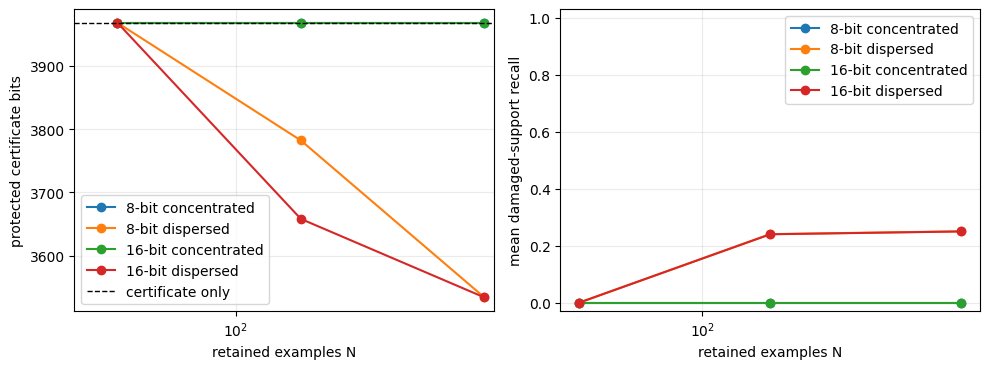

Separate resource accounting:


,layout,N,weight_bits,head_storage_GiB,accumulation_bits,output_bits,quantization_KL,quantization_TV,ordinary_output_MiB,certificate_bits,mean_abs_weight_change,mean_match_error,max_match_error,test_success,actual_decode_success,mean_damage_KL,mean_damage_TV
0,concentrated,64,8,0.489497,32,8,0.000182,0.007303,7.828125,3968,0.059230,0.000000,0.000000,1.0,1.0,0.001864,0.002157
1,concentrated,64,16,0.978516,32,8,0.000000,0.000000,7.828125,3968,0.059223,0.000077,0.000244,1.0,1.0,0.001871,0.002161
2,concentrated,128,8,0.489497,32,8,0.000182,0.007303,15.656250,3968,0.059230,0.000000,0.000000,1.0,1.0,0.001864,0.002157
3,concentrated,128,16,0.978516,32,8,0.000000,0.000000,15.656250,3968,0.059223,0.000077,0.000244,1.0,1.0,0.001871,0.002161
4,concentrated,256,8,0.489497,32,8,0.000182,0.007303,31.312500,3968,0.059230,0.000000,0.000000,1.0,1.0,0.001864,0.002157
5,concentrated,256,16,0.978516,32,8,0.000000,0.000000,31.312500,3968,0.059223,0.000077,0.000244,1.0,1.0,0.001871,0.002161
6,dispersed,64,8,0.489497,32,8,0.000182,0.007303,7.828125,3968,0.059602,0.000000,0.000000,1.0,1.0,0.005793,0.022857
7,dispersed,64,16,0.978516,32,8,0.000000,0.000000,7.828125,3968,0.059597,0.000077,0.000435,1.0,1.0,0.005786,0.022838
8,dispersed,128,8,0.489497,32,8,0.000182,0.007303,15.656250,3782,0.059602,0.000000,0.000000,1.0,1.0,0.005793,0.022857
9,dispersed,128,16,0.978516,32,8,0.000000,0.000000,15.656250,3658,0.059597,0.000077,0.000435,1.0,1.0,0.005786,0.022838


In [12]:
fig,axes=plt.subplots(1,2,figsize=(10,3.8))
for (bits,layout),g in summary.groupby(["weight_bits","layout"]):
    g=g.sort_values("N")
    label=f"{bits}-bit {layout}"
    axes[0].plot(g.N,g.certificate_bits,marker="o",label=label)
    axes[1].plot(g.N,g.mean_support_recall,marker="o",label=label)
axes[0].axhline(31*2*CFG.sparsity,color="black",ls="--",lw=1,label="certificate only")
axes[0].set(xlabel="retained examples N",ylabel="protected certificate bits",xscale="symlog")
axes[1].set(xlabel="retained examples N",ylabel="mean damaged-support recall",xscale="symlog",ylim=(-.03,1.03))
for ax in axes: ax.grid(alpha=.25); ax.legend()
fig.tight_layout(); fig.savefig(OUT/"certificate_vs_N.png",dpi=180); plt.show()

print("Separate resource accounting:")
display(summary[["layout","N","weight_bits","head_storage_GiB",
                 "accumulation_bits","output_bits","quantization_KL","quantization_TV",
                 "ordinary_output_MiB","certificate_bits","mean_abs_weight_change",
                 "mean_match_error","max_match_error",
                 "test_success","actual_decode_success","mean_damage_KL","mean_damage_TV"]])


## Stop rule

This experiment is interpretable only if BF16 and INT8 have closely matched signed changes, both layouts show nontrivial pre-repair damage, and test success remains high at the frozen development-selected budgets. INT4 appears only in the pre-tamper quantization table. Solver feasibility affects localization quality but not the algebraic certificate guarantee: every test trial executes the exact syndrome decoder and is counted successful only when its recovered patch equals the original sparse patch.

Do not add another dataset or precision from this notebook alone. First verify that `max_match_error` is small relative to `mean_abs_weight_change`, then compare the paired BF16 and INT8 certificate curves. Keep the earlier INT4 result as a secondary control because its baseline behavioral shift is substantial.
